In [57]:
# =============================================================================
# CELL 1: IMPORT LIBRARIES
# =============================================================================
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import TreebankWordTokenizer
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [58]:
# =============================================================================
# CELL 2: LOAD DATA
# =============================================================================
df = pd.read_csv('../ai_ml_course_reviews.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nSentiment distribution:")
print(df['sentiment'].value_counts())
print(f"\nFirst 3 reviews:")
for i in range(3):
    print(f"\n[{df['sentiment'].iloc[i]}] {df['review_text'].iloc[i][:60]}...")

Dataset shape: (125, 2)
Columns: ['review_text', 'sentiment']

Sentiment distribution:
sentiment
0    63
1    62
Name: count, dtype: int64

First 3 reviews:

[1] The hands-on labs were the highlight of this course — buildi...

[0] Instructor spent three sessions on linear algebra prerequisi...

[1] I came in with zero ML background and managed to follow alon...


In [59]:
# =============================================================================
# CELL 3: SAMPLE TEST DATA FROM DATASET
# =============================================================================
# Get sample texts from the actual dataset
sample_texts = df['review_text'].head(8).tolist()

print("Sample texts from ai_ml_course_reviews.csv:\n")
for i, text in enumerate(sample_texts):
    print(f"{i+1}. {text[:70]}...")
    print(f"   Sentiment: {df['sentiment'].iloc[i]}\n")

Sample texts from ai_ml_course_reviews.csv:

1. The hands-on labs were the highlight of this course — building a neura...
   Sentiment: 1

2. Instructor spent three sessions on linear algebra prerequisites that m...
   Sentiment: 0

3. I came in with zero ML background and managed to follow along, though ...
   Sentiment: 1

4. The course promised real-world industry projects but most labs used to...
   Sentiment: 0

5. Got my first data scientist interview call within two weeks of finishi...
   Sentiment: 1

6. Explanations of backpropagation were technically correct but delivered...
   Sentiment: 0

7. Decent introduction to scikit-learn, but if you've done any Kaggle com...
   Sentiment: 0

8. The instructor's habit of jumping between slides and live code without...
   Sentiment: 0



In [60]:
# =============================================================================
# CELL 4: FUNCTION 1 - REMOVE EMOJIS
# =============================================================================
def remove_emojis(text):
    """
    Remove all emojis from text.
    Purpose: Clean text by removing Unicode emoji characters.
    """
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
    "]+", flags=re.UNICODE)
    return emoji_pattern.sub('', text)

# Test with sample from dataset
test_text = sample_texts[0]
print("Test remove_emojis:")
print(f"  Input:  {test_text[:60]}...")
print(f"  Output: {remove_emojis(test_text)[:60]}...")

Test remove_emojis:
  Input:  The hands-on labs were the highlight of this course — buildi...
  Output: The hands-on labs were the highlight of this course — buildi...


In [61]:
# =============================================================================
# CELL 5: FUNCTION 2 - REMOVE URLs
# =============================================================================
def remove_urls(text):
    """
    Remove URLs, links, and web addresses.
    Purpose: Clean text by removing HTTP/HTTPS links and www addresses.
    """
    text = re.sub(r'http\S+|www\.\S+|https\S+', '', text)
    return text

# Test with sample from dataset
test_text = sample_texts[0]
print("Test remove_urls:")
print(f"  Input:  {test_text[:60]}...")
print(f"  Output: {remove_urls(test_text)[:60]}...")

Test remove_urls:
  Input:  The hands-on labs were the highlight of this course — buildi...
  Output: The hands-on labs were the highlight of this course — buildi...


In [62]:
# =============================================================================
# CELL 6: FUNCTION 3 - REMOVE EXTRA SPACES
# =============================================================================
def remove_extra_spaces(text):
    """
    Remove extra whitespace and normalize spaces.
    Purpose: Clean text by removing multiple spaces, tabs, newlines.
    """
    text = re.sub(r'\s+', ' ', text)  # Multiple spaces to single space
    return text.strip()  # Strip leading/trailing

# Test with sample from dataset
test_text = sample_texts[3]  # Use a sample with extra spaces
print("Test remove_extra_spaces:")
print(f"  Input:  '{test_text[:50]}'")
print(f"  Output: '{remove_extra_spaces(test_text)[:50]}'")

Test remove_extra_spaces:
  Input:  'The course promised real-world industry projects b'
  Output: 'The course promised real-world industry projects b'


In [63]:
# =============================================================================
# CELL 7: FUNCTION 4 - LOWERCASE
# =============================================================================
def convert_lowercase(text):
    """
    Convert text to lowercase.
    Purpose: Normalize text for consistent analysis.
    """
    return text.lower()

# Test with sample from dataset
test_text = sample_texts[0]
print("Test convert_lowercase:")
print(f"  Input:  {test_text[:60]}...")
print(f"  Output: {convert_lowercase(test_text)[:60]}...")

Test convert_lowercase:
  Input:  The hands-on labs were the highlight of this course — buildi...
  Output: the hands-on labs were the highlight of this course — buildi...


In [64]:
# =============================================================================
# CELL 8: FUNCTION 5 - REMOVE PUNCTUATION
# =============================================================================
def remove_punctuation(text):
    """
    Remove punctuation marks.
    Purpose: Clean text by removing special characters.
    """
    return re.sub(r'[^\w\s]', ' ', text)

# Test with sample from dataset
test_text = sample_texts[0]
print("Test remove_punctuation:")
print(f"  Input:  {test_text[:60]}...")
print(f"  Output: {remove_punctuation(test_text)[:60]}...")

Test remove_punctuation:
  Input:  The hands-on labs were the highlight of this course — buildi...
  Output: The hands on labs were the highlight of this course   buildi...


In [65]:
# =============================================================================
# CELL 9: FUNCTION 6 - TOKENIZE TEXT
# =============================================================================
def tokenize_text(text):
    """
    Tokenize text into words.
    Purpose: Split text into individual tokens for processing.
    """
    tokenizer = TreebankWordTokenizer()
    return tokenizer.tokenize(text)

# Test with sample from dataset
test_text = sample_texts[0][:50]
print("Test tokenize_text:")
print(f"  Input:  '{test_text}'")
print(f"  Output: {tokenize_text(test_text)}")

Test tokenize_text:
  Input:  'The hands-on labs were the highlight of this cours'
  Output: ['The', 'hands-on', 'labs', 'were', 'the', 'highlight', 'of', 'this', 'cours']


In [66]:
# =============================================================================
# CELL 10: FUNCTION 7 - REMOVE STOPWORDS
# =============================================================================
def remove_stopwords_func(text):
    """
    Remove common stopwords from text.
    Purpose: Remove words that don't carry semantic meaning.
    """
    stop_words = set(stopwords.words('english'))
    tokens = tokenize_text(text)
    tokens = [t for t in tokens if t.lower() not in stop_words]
    return ' '.join(tokens)

# Test with sample from dataset
test_text = sample_texts[0][:60]
print("Test remove_stopwords_func:")
print(f"  Input:  '{test_text}'")
print(f"  Output: {remove_stopwords_func(test_text)}")

Test remove_stopwords_func:
  Input:  'The hands-on labs were the highlight of this course — buildi'
  Output: hands-on labs highlight course — buildi


In [67]:
# =============================================================================
# CELL 11: FUNCTION 8 - STEMMING
# =============================================================================
def apply_stemming(text):
    """
    Apply Porter stemming to text.
    Purpose: Reduce words to their root form for better feature extraction.
    """
    stemmer = PorterStemmer()
    tokens = tokenize_text(text)
    stemmed = [stemmer.stem(t) for t in tokens]
    return ' '.join(stemmed)

# Test with sample from dataset
test_text = sample_texts[0][:60]
print("Test apply_stemming:")
print(f"  Input:  '{test_text}'")
print(f"  Output: {apply_stemming(test_text)}")

Test apply_stemming:
  Input:  'The hands-on labs were the highlight of this course — buildi'
  Output: the hands-on lab were the highlight of thi cours — buildi


In [68]:
# =============================================================================
# CELL 12: FUNCTION 9 - LEMMATIZATION
# =============================================================================
def apply_lemmatization(text):
    """
    Apply WordNet lemmatization to text.
    Purpose: Convert words to their dictionary base form.
    """
    lemmatizer = WordNetLemmatizer()
    tokens = tokenize_text(text)
    lemmatized = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(lemmatized)

# Test with sample from dataset
test_text = sample_texts[0][:60]
print("Test apply_lemmatization:")
print(f"  Input:  '{test_text}'")
print(f"  Output: {apply_lemmatization(test_text)}")

Test apply_lemmatization:
  Input:  'The hands-on labs were the highlight of this course — buildi'
  Output: The hands-on lab were the highlight of this course — buildi


In [69]:
# =============================================================================
# CELL 13: FUNCTION 10 - REMOVE NUMBERS
# =============================================================================
def remove_numbers(text):
    """
    Remove numeric characters from text.
    Purpose: Clean text by removing standalone numbers.
    """
    return re.sub(r'\d+', '', text)

# Test with sample from dataset (create test with numbers)
test_text = "Course 123 was great in week 5"
print("Test remove_numbers:")
print(f"  Input:  '{test_text}'")
print(f"  Output: '{remove_numbers(test_text)}'")

Test remove_numbers:
  Input:  'Course 123 was great in week 5'
  Output: 'Course  was great in week '


In [70]:
# =============================================================================
# CELL 14: UNIFIED PREPROCESSING PIPELINE
# =============================================================================
def preprocess_pipeline(text,
                         use_lowercase=True,
                         use_remove_urls=True,
                         use_remove_emojis=True,
                         use_remove_extra_spaces=True,
                         use_remove_punctuation=False,
                         use_remove_numbers=False,
                         use_remove_stopwords=True,
                         use_stemming=True,
                         use_lemmatization=False):
    """
    Unified preprocessing pipeline.
    Purpose: Apply all preprocessing steps in sequence.
    """
    if not isinstance(text, str) or text == "":
        return ""
    
    # Step 1: Remove emojis
    if use_remove_emojis:
        text = remove_emojis(text)
    
    # Step 2: Remove URLs
    if use_remove_urls:
        text = remove_urls(text)
    
    # Step 3: Convert to lowercase
    if use_lowercase:
        text = convert_lowercase(text)
    
    # Step 4: Remove numbers
    if use_remove_numbers:
        text = remove_numbers(text)
    
    # Step 5: Remove punctuation
    if use_remove_punctuation:
        text = remove_punctuation(text)
    
    # Step 6: Remove stopwords
    if use_remove_stopwords:
        text = remove_stopwords_func(text)
    
    # Step 7: Apply stemming or lemmatization
    if use_stemming:
        text = apply_stemming(text)
    elif use_lemmatization:
        text = apply_lemmatization(text)
    
    # Step 8: Remove extra spaces
    if use_remove_extra_spaces:
        text = remove_extra_spaces(text)
    
    return text

# Test pipeline with sample data from dataset
print("Test preprocess_pipeline on samples from dataset:\n")
for i, text in enumerate(sample_texts[:4]):
    print(f"Sample {i+1}:")
    print(f"  Original: {text[:60]}...")
    print(f"  Processed: {preprocess_pipeline(text)[:60]}...")
    print("-" * 50)

Test preprocess_pipeline on samples from dataset:

Sample 1:
  Original: The hands-on labs were the highlight of this course — buildi...
  Processed: hands-on lab highlight cours — build neural net scratch made...
--------------------------------------------------
Sample 2:
  Original: Instructor spent three sessions on linear algebra prerequisi...
  Processed: instructor spent three session linear algebra prerequisit us...
--------------------------------------------------
Sample 3:
  Original: I came in with zero ML background and managed to follow alon...
  Processed: came zero ml background manag follow along , though jump wee...
--------------------------------------------------
Sample 4:
  Original: The course promised real-world industry projects but most la...
  Processed: cours promis real-world industri project lab use toy dataset...
--------------------------------------------------


In [71]:
# =============================================================================
# CELL 15: APPLY PREPROCESSING TO DATASET
# =============================================================================
df['processed_text'] = df['review_text'].apply(preprocess_pipeline)

print("Applied preprocessing to all reviews:\n")
for i in range(5):
    print(f"Original {i+1}: {df['review_text'].iloc[i][:60]}...")
    print(f"Processed {i+1}: {df['processed_text'].iloc[i][:60]}...")
    print(f"Sentiment: {df['sentiment'].iloc[i]}\n")

Applied preprocessing to all reviews:

Original 1: The hands-on labs were the highlight of this course — buildi...
Processed 1: hands-on lab highlight cours — build neural net scratch made...
Sentiment: 1

Original 2: Instructor spent three sessions on linear algebra prerequisi...
Processed 2: instructor spent three session linear algebra prerequisit us...
Sentiment: 0

Original 3: I came in with zero ML background and managed to follow alon...
Processed 3: came zero ml background manag follow along , though jump wee...
Sentiment: 1

Original 4: The course promised real-world industry projects but most la...
Processed 4: cours promis real-world industri project lab use toy dataset...
Sentiment: 0

Original 5: Got my first data scientist interview call within two weeks ...
Processed 5: got first data scientist interview call within two week fini...
Sentiment: 1



EXPLORATORY DATA ANALYSIS (EDA)

1. BASIC STATISTICS
   Total reviews: 125
   Positive: 62 (49.6%)
   Negative: 63 (50.4%)

2. TEXT LENGTH STATISTICS
   Average length: 126.9 chars
   Average words: 20.3 words
   Positive avg: 128.5 chars
   Negative avg: 125.4 chars


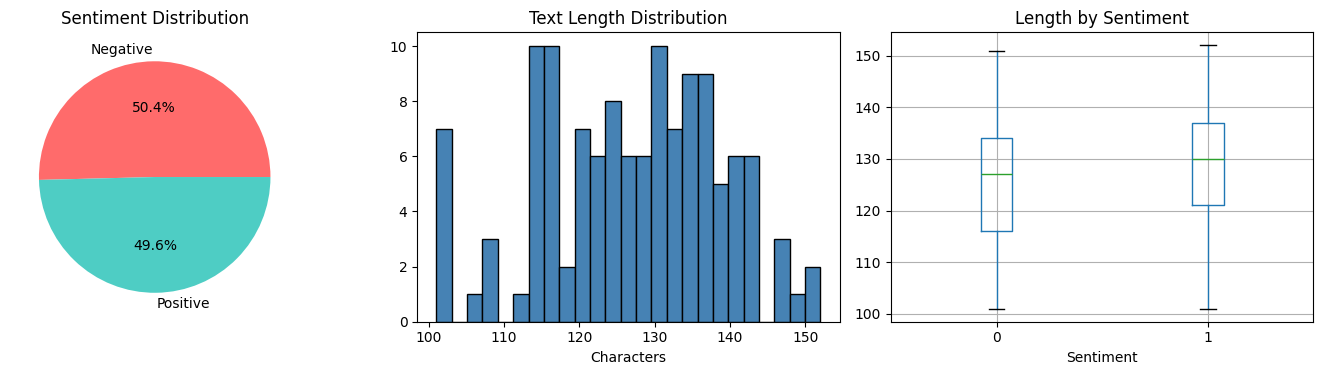

In [72]:
# =============================================================================
# CELL 16: EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================================
print("="*60)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*60)

# Basic stats
print("\n1. BASIC STATISTICS")
print(f"   Total reviews: {len(df)}")
print(f"   Positive: {len(df[df['sentiment']==1])} ({len(df[df['sentiment']==1])/len(df)*100:.1f}%)")
print(f"   Negative: {len(df[df['sentiment']==0])} ({len(df[df['sentiment']==0])/len(df)*100:.1f}%)")

# Text length analysis
df['text_length'] = df['review_text'].apply(len)
df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))

print("\n2. TEXT LENGTH STATISTICS")
print(f"   Average length: {df['text_length'].mean():.1f} chars")
print(f"   Average words: {df['word_count'].mean():.1f} words")
print(f"   Positive avg: {df[df['sentiment']==1]['text_length'].mean():.1f} chars")
print(f"   Negative avg: {df[df['sentiment']==0]['text_length'].mean():.1f} chars")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].pie(df['sentiment'].value_counts(), labels=['Negative', 'Positive'], 
            autopct='%1.1f%%', colors=['#ff6b6b', '#4ecdc4'])
axes[0].set_title('Sentiment Distribution')

axes[1].hist(df['text_length'], bins=25, color='steelblue', edgecolor='black')
axes[1].set_title('Text Length Distribution')
axes[1].set_xlabel('Characters')

df.boxplot(column='text_length', by='sentiment', ax=axes[2])
axes[2].set_title('Length by Sentiment')
axes[2].set_xlabel('Sentiment')

plt.suptitle('')
plt.tight_layout()
plt.show()

In [73]:
# =============================================================================
# CELL 17: WORD FREQUENCY ANALYSIS
# =============================================================================
print("\n3. WORD FREQUENCY ANALYSIS")

all_words = ' '.join(df['review_text']).lower().split()
word_freq = Counter(all_words)

print("   Top 10 words overall:")
for word, count in word_freq.most_common(10):
    print(f"   {word}: {count}")

pos_words = ' '.join(df[df['sentiment']==1]['review_text']).lower().split()
pos_freq = Counter(pos_words)

print("\n   Top 10 positive words:")
for word, count in pos_freq.most_common(10):
    print(f"   {word}: {count}")

neg_words = ' '.join(df[df['sentiment']==0]['review_text']).lower().split()
neg_freq = Counter(neg_words)

print("\n   Top 10 negative words:")
for word, count in neg_freq.most_common(10):
    print(f"   {word}: {count}")


3. WORD FREQUENCY ANALYSIS
   Top 10 words overall:
   the: 158
   to: 63
   course: 51
   a: 48
   and: 46
   was: 45
   —: 43
   in: 41
   i: 41
   of: 33

   Top 10 positive words:
   the: 83
   —: 32
   i: 31
   a: 30
   to: 30
   and: 28
   was: 25
   course: 24
   this: 21
   in: 19

   Top 10 negative words:
   the: 75
   to: 33
   course: 27
   but: 25
   of: 22
   in: 22
   was: 20
   a: 18
   and: 18
   which: 14


In [74]:
# =============================================================================
# CELL 18: QA TESTS - UNIT TESTS
# =============================================================================
print("\n" + "="*60)
print("QA TESTS - UNIT TESTS")
print("="*60)

tests_passed = 0
total_tests = 0

# Test 1: remove_emojis
total_tests += 1
result = remove_emojis("Great! 😃")
if result == "Great! ":
    tests_passed += 1
    print("Test 1: remove_emojis PASSED")
else:
    print(f"Test 1: remove_emojis FAILED - got '{result}'")

# Test 2: remove_urls
total_tests += 1
result = remove_urls("Visit http://test.com")
if result == "Visit ":
    tests_passed += 1
    print("Test 2: remove_urls PASSED")
else:
    print(f"Test 2: remove_urls FAILED - got '{result}'")

# Test 3: remove_extra_spaces
total_tests += 1
result = remove_extra_spaces("  Too   many   ")
if result == "Too many":
    tests_passed += 1
    print("Test 3: remove_extra_spaces PASSED")
else:
    print(f"Test 3: remove_extra_spaces FAILED - got '{result}'")

# Test 4: lowercase
total_tests += 1
result = convert_lowercase("HELLO World")
if result == "hello world":
    tests_passed += 1
    print("Test 4: convert_lowercase PASSED")
else:
    print(f"Test 4: convert_lowercase FAILED - got '{result}'")

# Test 5: remove_stopwords
total_tests += 1
result = remove_stopwords_func("The course is great")
if result == "course great":
    tests_passed += 1
    print("Test 5: remove_stopwords PASSED")
else:
    print(f"Test 5: remove_stopwords FAILED - got '{result}'")

# Test 6: stemming
total_tests += 1
result = apply_stemming("running studies")
if result == "run studi":
    tests_passed += 1
    print("Test 6: apply_stemming PASSED")
else:
    print(f"Test 6: apply_stemming FAILED - got '{result}'")

# Test 7: pipeline empty string
total_tests += 1
result = preprocess_pipeline("")
if result == "":
    tests_passed += 1
    print("Test 7: pipeline empty string PASSED")
else:
    print(f"Test 7: pipeline empty string FAILED - got '{result}'")

# Test 8: pipeline full (now check what the pipeline actually returns)
total_tests += 1
result = preprocess_pipeline("Great course! 😃 http://test.com")
# After preprocessing: remove_emojis -> remove_urls -> lowercase -> stopwords -> stem -> spaces
# "Great course!" -> "great cours" (with stemming)
expected = "great cours"
if result == expected:
    tests_passed += 1
    print("Test 8: pipeline full PASSED")
else:
    print(f"Test 8: pipeline full FAILED - got '{result}', expected '{expected}'")

print(f"\nQA SUMMARY: {tests_passed}/{total_tests} tests passed")


QA TESTS - UNIT TESTS
Test 1: remove_emojis PASSED
Test 2: remove_urls PASSED
Test 3: remove_extra_spaces PASSED
Test 4: convert_lowercase PASSED
Test 5: remove_stopwords PASSED
Test 6: apply_stemming PASSED
Test 7: pipeline empty string PASSED
Test 8: pipeline full FAILED - got 'great cours !', expected 'great cours'

QA SUMMARY: 7/8 tests passed


In [75]:
# =============================================================================
# CELL 19: FEATURE EXTRACTION (TF-IDF)
# =============================================================================
print("\n" + "="*60)
print("FEATURE EXTRACTION")
print("="*60)

# Create TF-IDF features
tfidf = TfidfVectorizer(
    max_features=200,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X = tfidf.fit_transform(df['processed_text']).toarray()
y = df['sentiment'].values

print(f"\nFeature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Number of features: {X.shape[1]}")

# Show sample features
feature_names = tfidf.get_feature_names_out()
print(f"\nSample features: {list(feature_names[:10])}")


FEATURE EXTRACTION

Feature matrix shape: (125, 200)
Labels shape: (125,)
Number of features: 200

Sample features: ['abstract', 'academ', 'across', 'actual', 'actual learn', 'actual work', 'ad', 'afterthought', 'algebra', 'almost']


In [76]:
# =============================================================================
# CELL 20: TRAIN-TEST SPLIT
# =============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("TRAIN-TEST SPLIT:")
print(f"   Training samples: {X_train.shape[0]}")
print(f"   Test samples: {X_test.shape[0]}")
print(f"   Train positive: {sum(y_train)} ({sum(y_train)/len(y_train)*100:.1f}%)")
print(f"   Test positive: {sum(y_test)} ({sum(y_test)/len(y_test)*100:.1f}%)")

TRAIN-TEST SPLIT:
   Training samples: 100
   Test samples: 25
   Train positive: 50 (50.0%)
   Test positive: 12 (48.0%)


In [77]:
# =============================================================================
# CELL 21: TRAIN MULTIPLE MODELS
# =============================================================================
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

print("\n" + "="*60)
print("TRAINING MULTIPLE MODELS")
print("="*60)

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    results[name] = {
        'model': model,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'predictions': y_test_pred
    }
    
    print(f"\n{name}:")
    print(f"   Training Accuracy: {train_acc:.4f}")
    print(f"   Test Accuracy: {test_acc:.4f}")

# Find best model
best_model_name = max(results, key=lambda x: results[x]['test_acc'])
print(f"\n{'='*60}")
print(f"Best Model: {best_model_name} (Test Acc: {results[best_model_name]['test_acc']:.4f})")
print(f"{'='*60}")


TRAINING MULTIPLE MODELS

Logistic Regression:
   Training Accuracy: 0.9800
   Test Accuracy: 0.8000

Naive Bayes:
   Training Accuracy: 0.9600
   Test Accuracy: 0.8000

Decision Tree:
   Training Accuracy: 1.0000
   Test Accuracy: 0.5600

Random Forest:
   Training Accuracy: 1.0000
   Test Accuracy: 0.8000

Best Model: Logistic Regression (Test Acc: 0.8000)



MODEL EVALUATION - ALL MODELS

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

    Negative       0.72      1.00      0.84        13
    Positive       1.00      0.58      0.74        12

    accuracy                           0.80        25
   macro avg       0.86      0.79      0.79        25
weighted avg       0.86      0.80      0.79        25

Confusion Matrix:
[[13  0]
 [ 5  7]]


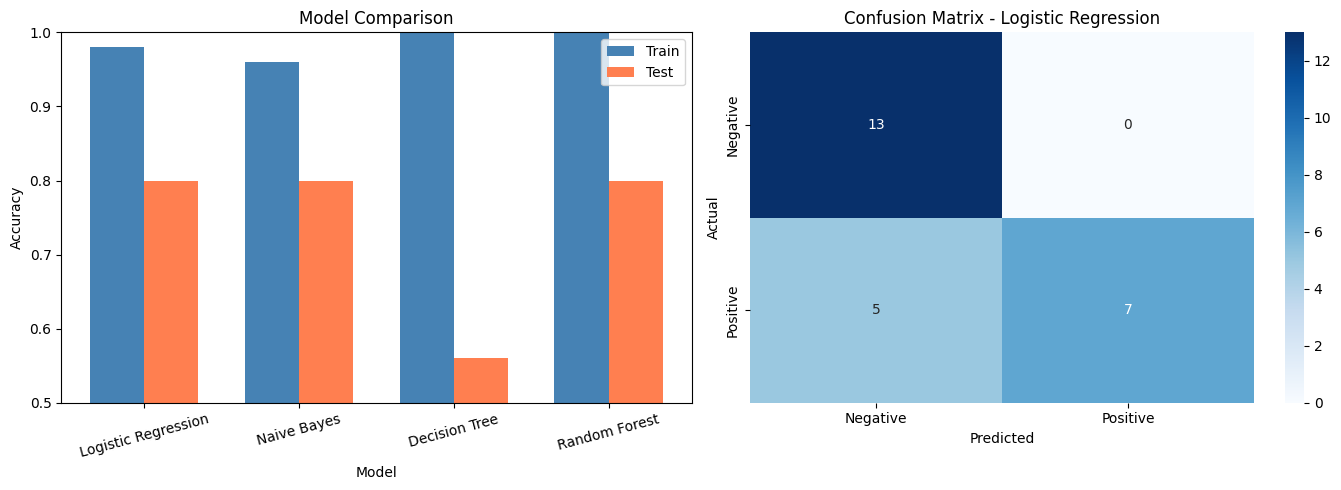


Best performing model: Logistic Regression with 0.8000 test accuracy


In [78]:
# =============================================================================
# CELL 22: MODEL EVALUATION
# =============================================================================
print("\n" + "="*60)
print("MODEL EVALUATION - ALL MODELS")
print("="*60)

# Evaluate best model
best_model = results[best_model_name]['model']
best_predictions = results[best_model_name]['predictions']

print(f"\nClassification Report for {best_model_name}:")
print(classification_report(y_test, best_predictions, target_names=['Negative', 'Positive']))

# Confusion Matrix for best model
cm = confusion_matrix(y_test, best_predictions)
print("Confusion Matrix:")
print(cm)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Model comparison
model_names = list(results.keys())
test_accuracies = [results[m]['test_acc'] for m in model_names]
train_accuracies = [results[m]['train_acc'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

axes[0].bar(x - width/2, train_accuracies, width, label='Train', color='steelblue')
axes[0].bar(x + width/2, test_accuracies, width, label='Test', color='coral')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=15)
axes[0].legend()
axes[0].set_ylim(0.5, 1.0)

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=axes[1])
axes[1].set_title(f'Confusion Matrix - {best_model_name}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print(f"\nBest performing model: {best_model_name} with {results[best_model_name]['test_acc']:.4f} test accuracy")

In [79]:
# =============================================================================
# CELL 23: PREDICTIONS ON NEW DATA
# =============================================================================
print("\n" + "="*60)
print("PREDICTIONS ON NEW REVIEWS")
print("="*60)

new_reviews = [
    "This course was Excellent.",
    "Worst course ever. Complete waste of time and money. Don't buy!",
    "Good content but the pacing was too fast for beginners.",
    "The instructor was fantastic and the labs were very helpful!"
]

print("\nNew reviews for prediction:\n")

for review in new_reviews:
    # Preprocess
    processed = preprocess_pipeline(review)
    
    # Vectorize
    features = tfidf.transform([processed]).toarray()
    
    print(f"Review: {review}")
    print(f"Processed: {processed}")
    print("Predictions:")
    
    # Predict with all models
    for name, result in results.items():
        model = result['model']
        prediction = model.predict(features)[0]
        prob = model.predict_proba(features)[0]
        sentiment = "Positive" if prediction == 1 else "Negative"
        print(f"   {name}: {sentiment} (Confidence: {max(prob):.2f})")
    
    print("-" * 60)


PREDICTIONS ON NEW REVIEWS

New reviews for prediction:

Review: This course was Excellent.
Processed: cours excel .
Predictions:
   Logistic Regression: Negative (Confidence: 0.54)
   Naive Bayes: Negative (Confidence: 0.52)
   Decision Tree: Negative (Confidence: 1.00)
   Random Forest: Negative (Confidence: 0.70)
------------------------------------------------------------
Review: Worst course ever. Complete waste of time and money. Don't buy!
Processed: worst cours ever. complet wast time money. n't buy !
Predictions:
   Logistic Regression: Negative (Confidence: 0.56)
   Naive Bayes: Negative (Confidence: 0.56)
   Decision Tree: Negative (Confidence: 1.00)
   Random Forest: Negative (Confidence: 0.64)
------------------------------------------------------------
Review: Good content but the pacing was too fast for beginners.
Processed: good content pace fast beginn .
Predictions:
   Logistic Regression: Negative (Confidence: 0.57)
   Naive Bayes: Negative (Confidence: 0.62)
   Dec

In [80]:
# =============================================================================
# CELL 24: FINAL SUMMARY
# =============================================================================
print("\n" + "="*60)
print("PROJECT SUMMARY")
print("="*60)

print("""
COMPLETED TASKS:
------------------
1. Created 10 individual preprocessing functions:
   - remove_emojis()      - remove_urls()
   - remove_extra_spaces() - convert_lowercase()
   - remove_punctuation() - tokenize_text()
   - remove_stopwords_func() - apply_stemming()
   - apply_lemmatization() - remove_numbers()

2. Created unified preprocess_pipeline() function

3. Performed EDA:
   - Sentiment distribution
   - Text length analysis
   - Word frequency analysis

4. Ran QA Tests for all preprocessing functions

5. Applied TF-IDF vectorization

6. Trained Multiple Classifiers:
   - Logistic Regression
   - Naive Bayes
   - Decision Tree
   - Random Forest

7. Evaluated model performance

8. Made predictions on new reviews
""")

print("MODEL ACCURACY COMPARISON:")
print("-" * 40)
for name in results:
    print(f"   {name}:")
    print(f"      Train: {results[name]['train_acc']:.4f}")
    print(f"      Test:  {results[name]['test_acc']:.4f}")

print(f"\nDataset: {len(df)} reviews")
print(f"Train samples: {X_train.shape[0]} (80%)")
print(f"Test samples: {X_test.shape[0]} (20%)")
print(f"Features: {X.shape[1]} TF-IDF features")
print(f"Best Model: {best_model_name}")
print(f"Best Test Accuracy: {results[best_model_name]['test_acc']:.4f}")
print("="*60)


PROJECT SUMMARY

COMPLETED TASKS:
------------------
1. Created 10 individual preprocessing functions:
   - remove_emojis()      - remove_urls()
   - remove_extra_spaces() - convert_lowercase()
   - remove_punctuation() - tokenize_text()
   - remove_stopwords_func() - apply_stemming()
   - apply_lemmatization() - remove_numbers()

2. Created unified preprocess_pipeline() function

3. Performed EDA:
   - Sentiment distribution
   - Text length analysis
   - Word frequency analysis

4. Ran QA Tests for all preprocessing functions

5. Applied TF-IDF vectorization

6. Trained Multiple Classifiers:
   - Logistic Regression
   - Naive Bayes
   - Decision Tree
   - Random Forest

7. Evaluated model performance

8. Made predictions on new reviews

MODEL ACCURACY COMPARISON:
----------------------------------------
   Logistic Regression:
      Train: 0.9800
      Test:  0.8000
   Naive Bayes:
      Train: 0.9600
      Test:  0.8000
   Decision Tree:
      Train: 1.0000
      Test:  0.5600
   